# My Kyler deck vs. the corpus

Loads the real decklist at `data/fixtures/my_decks/kyler.txt` (the same fixture
`edhcut.ingest.qa_report` already checks resolves cleanly) and compares each of its 99 library
cards against everything gathered so far for the Kyler slot:

- **deck_count**: how many of the 300 Kyler decks in the corpus (`decks` where
  `commander_oracle_id` is Kyler) also run this card -- direct count, not scoped to any
  co-occurrence pool threshold.
- **in_precon**: whether the card shipped in Kyler's own matched precon ("Coven Counters"),
  same `precon_cards` table `precon_exploration.ipynb` uses.
- **synergizes_with** / **%over_baseline**: this card's highest-`lift` partner in the Kyler-scope
  association matrix (`edhcut.analysis.cooccurrence`, `lift_kyler.npz`), land/nonland-matched
  (a land only suggests another land and vice versa, unless the cross-type lift exceeds 5 --
  otherwise the same-type runner-up is shown instead). `%over_baseline` is that lift value
  restated as `round((lift - 1) * 100)` -- how many percent more often the pair co-occurs than
  chance alone would predict (0 = exactly chance, negative = *less* than chance).
- **pair_count**: how many of the 300 Kyler decks run *both* this card and its
  `synergizes_with` partner -- the raw evidence behind `%over_baseline`, direct-counted rather
  than read off the (weighted) co-occurrence matrix.

No network calls -- everything here reads already-populated tables and the precomputed
`data/kb/dev/` matrices.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from edhcut.analysis.cooccurrence import KB_DEV_DIR, load_card_index
from edhcut.config import CONFIG
from edhcut.db import connect
from edhcut.images import get_card_image
from edhcut.http import get_session
from edhcut.ingest.edhrec import resolve_oracle_id

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 60)

# Keep the context-manager object itself alive (not just the yielded `conn`) -- otherwise the
# generator-based context manager can get garbage-collected mid-notebook, which runs its own
# `finally: conn.close()` and closes the connection out from under later cells.
_db_ctx = connect(CONFIG.paths.db_path)
conn = _db_ctx.__enter__()

img_session = get_session("scryfall")

KYLER_NAME = "Kyler, Sigardian Emissary"
DECKLIST_PATH = Path(CONFIG.paths.fixtures_dir) / "kyler.txt"

## Parse the decklist

Same plain `qty name` format `edhcut.ingest.qa_report.parse_fixture_decklist` parses, but that
helper discards quantity (it only checks whether names resolve) -- reimplemented here to keep
`qty` per line, since a basic land's actual copy count is worth showing.

In [2]:
QTY_PREFIX_RE = re.compile(r"^(\d+)x?\s+(.+)$")

commander_id = resolve_oracle_id(conn, KYLER_NAME)
library_entries: list[tuple[int, str]] = []
for raw_line in DECKLIST_PATH.read_text(encoding="utf-8").splitlines():
    line = raw_line.strip()
    if not line or line.lower().startswith("commander:"):
        continue
    match = QTY_PREFIX_RE.match(line)
    if match:
        library_entries.append((int(match.group(1)), match.group(2).strip()))

deck_df = pd.DataFrame(
    {"name": name, "oracle_id": resolve_oracle_id(conn, name), "qty": qty}
    for qty, name in library_entries
)

unresolved = deck_df[deck_df["oracle_id"].isna()]
print(f"{len(deck_df)} distinct library cards, {deck_df['qty'].sum()} physical copies "
      f"({len(unresolved)} unresolved)")
if not unresolved.empty:
    print("unresolved:", unresolved["name"].tolist())

93 distinct library cards, 99 physical copies (0 unresolved)


## Enrich each card against the corpus

`deck_count` is a direct `deck_cards`/`decks` query (exact, not limited to
`edhcut.analysis.cooccurrence`'s global >=3-deck pool) -- some cards in a single real decklist
are niche enough to sit below that pool threshold, and a direct count still answers "how many
of the 300" correctly for those. `synergizes_with` *is* limited to that pool, since lift itself
is only defined there -- shown as missing (`NaN`) for cards outside it.

**Land/nonland matching**: `lift_kyler`'s single overall-best partner for a card is picked
without regard to card type, which can pair a land with a nonland spell (or vice versa) purely
because that pairing happens to have the least-diluted lift value -- not necessarily the most
*useful* suggestion for a deckbuilder thinking in terms of "what land goes with this land" or
"what spell goes with this spell." So the same-type candidate is preferred: the overall-best
partner is only shown as-is when its lift exceeds 5 (a strong enough signal to cross the
land/nonland boundary); otherwise the highest-lift *same-type* partner is shown instead.

In [3]:
# Same precon Kyler matches elsewhere in this project (precon_exploration.ipynb section 3).
precon_id = conn.execute(
    "SELECT DISTINCT precon_id FROM precon_card_retention WHERE commander_key = ?", (commander_id,)
).fetchone()[0]

deck_counts = {}
for oracle_id in deck_df["oracle_id"]:
    deck_counts[oracle_id] = conn.execute(
        """
        SELECT COUNT(DISTINCT dc.deck_id) FROM deck_cards dc
        JOIN decks d ON d.deck_id = dc.deck_id
        WHERE d.commander_oracle_id = ? AND dc.oracle_id = ?
        """,
        (commander_id, oracle_id),
    ).fetchone()[0]
deck_df["deck_count"] = deck_df["oracle_id"].map(deck_counts)

is_land_by_oid = dict(conn.execute("SELECT oracle_id, is_land FROM cards").fetchall())
deck_df["is_land"] = deck_df["oracle_id"].map(is_land_by_oid).astype(bool)

precon_card_ids = {
    oracle_id
    for (oracle_id,) in conn.execute("SELECT oracle_id FROM precon_cards WHERE precon_id = ?", (precon_id,))
    if oracle_id != commander_id
}
deck_df["in_precon"] = deck_df["oracle_id"].isin(precon_card_ids)

card_index = load_card_index()
row_by_oid = dict(zip(card_index["oracle_id"], card_index["row"]))
name_by_row = dict(zip(card_index["row"], card_index["name"]))
oid_by_name = dict(zip(card_index["name"], card_index["oracle_id"]))
is_land_by_row = card_index["oracle_id"].map(is_land_by_oid).astype(bool).to_numpy()
CROSS_TYPE_LIFT_FLOOR = 5.0
lift_kyler = sparse.load_npz(KB_DEV_DIR / "lift_kyler.npz")


def best_lift_partner(oracle_id: str, source_is_land: bool) -> tuple[str | None, float]:
    row = row_by_oid.get(oracle_id)
    if row is None:
        return None, float("nan")
    entries = lift_kyler.getrow(row).tocoo()
    if entries.nnz == 0:
        return None, float("nan")
    order = np.argsort(entries.data)[::-1]  # highest lift first
    cols, values = entries.col[order], entries.data[order]

    best_col, best_value = cols[0], values[0]
    if best_value > CROSS_TYPE_LIFT_FLOOR:
        return name_by_row[best_col], float(best_value)

    same_type = is_land_by_row[cols] == source_is_land
    if not same_type.any():
        return None, float("nan")
    col = cols[same_type][0]
    value = values[same_type][0]
    return name_by_row[col], float(value)


partner_info = [
    best_lift_partner(oracle_id, is_land)
    for oracle_id, is_land in zip(deck_df["oracle_id"], deck_df["is_land"])
]
deck_df["synergizes_with"] = [p[0] for p in partner_info]
lift = pd.Series([p[1] for p in partner_info], index=deck_df.index)
deck_df["%over_baseline"] = ((lift - 1) * 100).round().astype("Int64")


def pair_count(oracle_id: str, partner_name: str | None) -> float:
    # `partner_name` came back out of a pandas column, so a missing entry surfaces as float
    # NaN here even though the list that built the column held Python `None` -- pandas
    # silently converts `None` to `NaN` on assignment into an object-dtype column.
    if pd.isna(partner_name):
        return float("nan")
    partner_id = oid_by_name.get(partner_name)
    return conn.execute(
        """
        SELECT COUNT(DISTINCT d.deck_id) FROM decks d
        JOIN deck_cards dc1 ON dc1.deck_id = d.deck_id AND dc1.oracle_id = ?
        JOIN deck_cards dc2 ON dc2.deck_id = d.deck_id AND dc2.oracle_id = ?
        WHERE d.commander_oracle_id = ?
        """,
        (oracle_id, partner_id, commander_id),
    ).fetchone()[0]


deck_df["pair_count"] = [
    pair_count(oracle_id, partner_name)
    for oracle_id, partner_name in zip(deck_df["oracle_id"], deck_df["synergizes_with"])
]

deck_df = deck_df.sort_values("deck_count", ascending=False).reset_index(drop=True)

print(f"{(deck_df['synergizes_with'].isna()).sum()} cards have no lift data "
      f"(below the global >=3-deck co-occurrence pool)")
deck_df[["name", "qty", "deck_count", "in_precon", "synergizes_with", "%over_baseline", "pair_count"]]

18 cards have no lift data (below the global >=3-deck co-occurrence pool)


,name,qty,deck_count,in_precon,synergizes_with,%over_baseline,pair_count
0,Forest,4,291,True,Temple of the False God,3,49.0
1,Plains,4,291,True,Temple of the False God,3,49.0
2,Command Tower,1,285,True,Witch's Clinic,5,6.0
3,Champion of Lambholt,1,282,True,Humble Naturalist,6,4.0
4,Heronblade Elite,1,274,True,Gyre Sage,9,14.0
5,Sol Ring,1,267,True,"Mondrak, Glory Dominus",12,5.0
6,Canopy Vista,1,257,True,Misty Rainforest,17,7.0
7,"Katilda, Dawnhart Prime",1,250,False,Nature's Rhythm,20,3.0
8,Avacyn's Pilgrim,1,244,True,Dawnbringer Cleric,23,5.0
9,Swords to Plowshares,1,239,True,Dawnhart Wardens,26,4.0


## Card popularity in my deck

`deck_count` for all 93 library cards, sorted most- to least-popular (same order as the table
above), colored by `in_precon` — a quick visual for how the deck splits between "safe,
widely-played" choices and the long tail of cards nobody else in the corpus runs much.

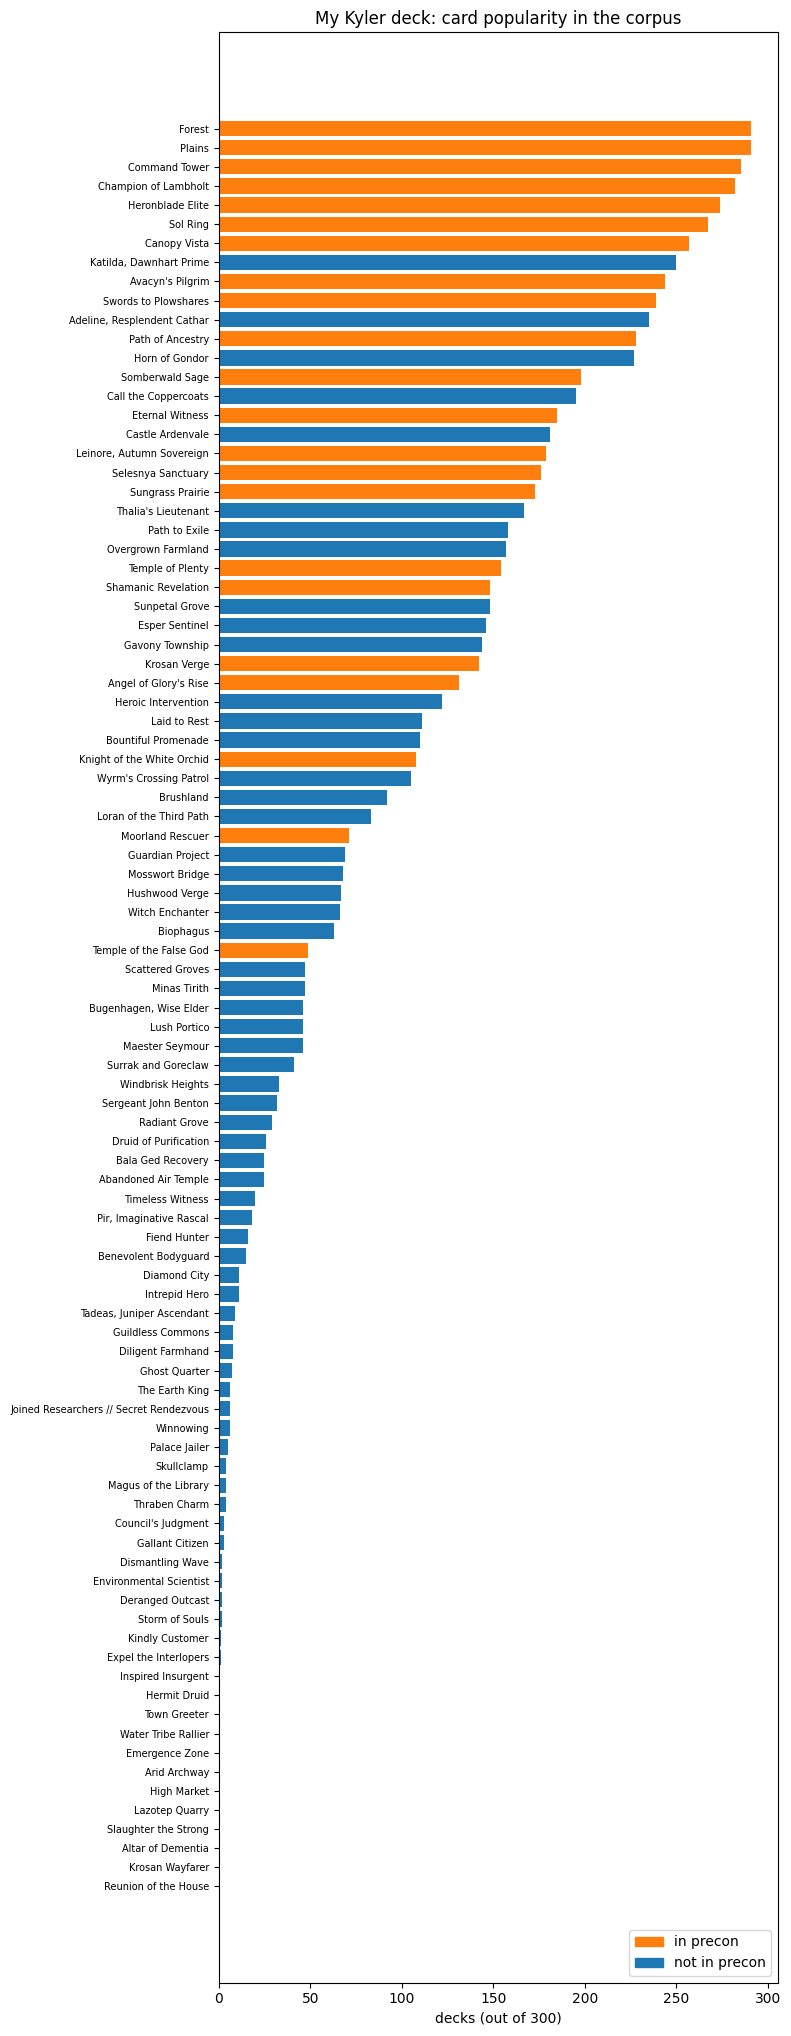

In [4]:
plot_df = deck_df.sort_values("deck_count", ascending=True)  # ascending so the barh reads top-to-bottom
colors = plot_df["in_precon"].map({True: "tab:orange", False: "tab:blue"})

fig, ax = plt.subplots(figsize=(8, 0.22 * len(plot_df)))
ax.barh(plot_df["name"], plot_df["deck_count"], color=colors)
ax.set_xlabel("decks (out of 300)")
ax.set_title("My Kyler deck: card popularity in the corpus")
ax.tick_params(axis="y", labelsize=7)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="tab:orange", label="in precon"),
    plt.Rectangle((0, 0), 1, 1, color="tab:blue", label="not in precon"),
]
ax.legend(handles=handles, loc="lower right")
fig.tight_layout()
plt.show()

**Caveat on `%over_baseline` for near-ubiquitous cards**: 0% means "exactly as often together as
chance would predict" -- for a card like a basic land that's in almost every deck, its highest
value can still land barely above 0% (e.g. ~3%), which isn't a real synergy signal, just the
least-diluted pairing available for a card whose own marginal count is enormous. Worth reading
`%over_baseline` next to `pair_count`/`deck_count`, not in isolation -- a small percentage over
a large `pair_count` is a very different claim than the same percentage over a handful of decks.

## Highlight: cards unique to my build

Nonland cards in my deck that **zero** of the other 300 Kyler decks in the corpus run at all --
not "rare," genuinely unseen elsewhere in this dataset.

8 nonland cards with deck_count == 0


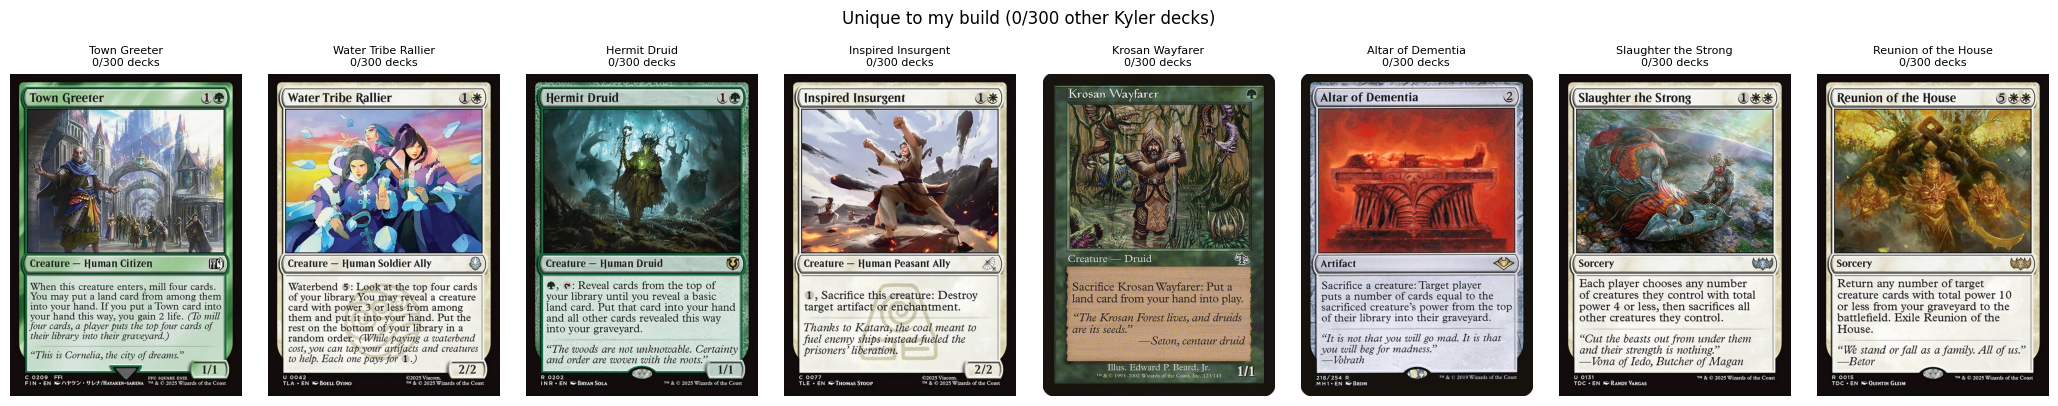

In [5]:
def show_card_row(conn, rows: pd.DataFrame, title: str, caption_fn) -> None:
    n = len(rows)
    if n == 0:
        print(f"({title}: none)")
        return
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 4.1))
    if n == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        image = get_card_image(conn, row["name"], session=img_session)
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"{row['name']}\n{caption_fn(row)}", fontsize=8)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


unique_to_me = deck_df[(deck_df["deck_count"] == 0) & (~deck_df["is_land"])]
print(f"{len(unique_to_me)} nonland cards with deck_count == 0")
show_card_row(conn, unique_to_me, "Unique to my build (0/300 other Kyler decks)", lambda r: "0/300 decks")

## Highlight: confirmed synergy pairs

Cards in my deck whose land/nonland-matched best partner (within the Kyler-scope pool) is
*also* in my deck -- a real pairing I've actually built around, not just a plausible one.

In [6]:
my_card_names = set(deck_df["name"])
confirmed_pairs = deck_df[deck_df["synergizes_with"].isin(my_card_names)].sort_values(
    "%over_baseline", ascending=False
)
print(f"{len(confirmed_pairs)} cards whose best partner is also in my deck")
confirmed_pairs[["name", "synergizes_with", "%over_baseline", "pair_count", "deck_count"]]

9 cards whose best partner is also in my deck


,name,synergizes_with,%over_baseline,pair_count,deck_count
72,Magus of the Library,Intrepid Hero,2627,4.0,4
61,Intrepid Hero,Magus of the Library,2627,4.0,11
64,Guildless Commons,Timeless Witness,650,4.0,8
56,Timeless Witness,Guildless Commons,650,4.0,20
39,Mosswort Bridge,Windbrisk Heights,221,24.0,68
25,Sunpetal Grove,Ghost Quarter,103,7.0,148
18,Selesnya Sanctuary,Guildless Commons,70,8.0,176
0,Forest,Temple of the False God,3,49.0,291
1,Plains,Temple of the False God,3,49.0,291
